# Теория информации и кодирования
## Основные понятия
Сегодня мы разберем на практике понятия, которые рассматривали на лекции: информация, сообщение, сигнал, количество информации, энтропия, дискретизация и квантование.

## Наши задачи на сегодня

* получить запись одного и того же звукового сигнала с разной частотой дискретизации и квантизацией.
* сравнить разборчивость голоса, и выбрать оптимальный вариант, когда голос еще разборчив, а сообщение занимает как можно меньше места
* вычислить количество информации и энтропию сигнала в разных форматах записи

Начнем с подготовки: импорта необходимых нам библиотек

In [24]:
# установим необходимые пакеты
!pip install numpy scipy matplotlib pandas sounddevice soundfile requests

# импортируем нужные нам пакеты
import sys
import math
from pathlib import Path

import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal
from scipy.io import wavfile
from IPython.display import Audio, display, Markdown

print(f"Версия Python: {sys.version.split()[0]}")
print(f"Текущая рабочая папка: {Path.cwd()}")

Версия Python: 3.8.1
Текущая рабочая папка: /home/aleksandr/Documents/Learning/2026-2027/1/InfromationAndCodingTheory


Мы начнем с работы со звуком. Давайте загрузим файл (да, он уже оцифрован, для получения файла выполнены дискретизация и квантование), но нам нужно что-то, с чем мы можем начать.

> Если вы запускаете этот блокнот локально, вы можете записать и использовать в дальнейшшем вашу собственную запись

Частота дискретизации: 44100 Гц
Тип данных: int16
Форма массива: (220526,)
Первые 10 отсчётов: [32767 32767 32767 32767 32767 32767 32767 32767 32767 32767]
10 отсчётов, начиная с 1 секунды: [-461 -708 -822 -750 -583 -430 -460 -526 -554 -532]


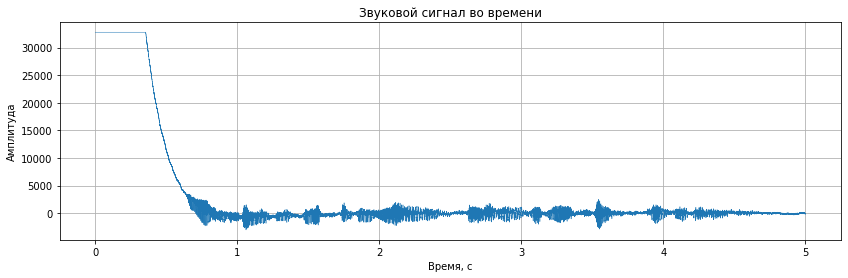

In [25]:
import io
import requests
from scipy.io import wavfile

from IPython.display import Audio, display
import matplotlib.pyplot as plt

record1_url = "https://alstutor.work/files/Record1.wav"

response1 = requests.get(record1_url, timeout=30)
response1.raise_for_status()

# response.content содержит файл как набор байтов.
# BytesIO позволяет работать с этими байтами как с файлом.
sample_rate1, audio1 = wavfile.read(io.BytesIO(response1.content))

# выделим один канал и будем дальше работать с ним
audio1 = audio1[:, 1]

print("Частота дискретизации:", sample_rate1, "Гц")
print("Тип данных:", audio1.dtype)
print("Форма массива:", audio1.shape)
print("Первые 10 отсчётов:", audio1[:10])
print("10 отсчётов, начиная с 1 секунды:", audio1[44100:44110])

display(Audio(audio1, rate=44100))

time = np.arange(len(audio1)) / sample_rate1

plt.figure(figsize=(14, 4))
plt.plot(time, audio1, linewidth=0.5)

plt.title("Звуковой сигнал во времени")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.grid(True)

plt.show()

> Самостоятельно

Пожалуйста, проделайте все то же самое для второй записи в ячейке ниже

In [ ]:
# аналогичный анализ для второй записи
record2_url = "https://alstutor.work/files/Record2.wav"

> Самостоятельно:
Пожалуйста, рассчитайте и напишите в ячейке ниже:

* каков должен быть предполагаемый размер файла при заданных параметрах звука
* отличается ли реальный размер файла
* насколько
* как вы считаете, почему
* почему цифры в первых 10 отсчетах одинаковы и как это связано с графиком
* что вы можете сказать о записи тишины, как она отличается от записи голоса

Затем постройте график первой записи на интервале между 0.8 и 0.81 секунды.
Что вы можете сказать об этом графике?

Выводы:

In [ ]:
# график записи на интервале между 0.8 и 0.81 секунды

Важным элементом является [спектрограмма сигнала](https://ru.wikipedia.org/wiki/Спектрограмма). Двайте построим спектрограмму нашего звука

/home/aleksandr/miniconda3/envs/math/lib/python3.8/site-packages/matplotlib/axes/_axes.py:7581: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


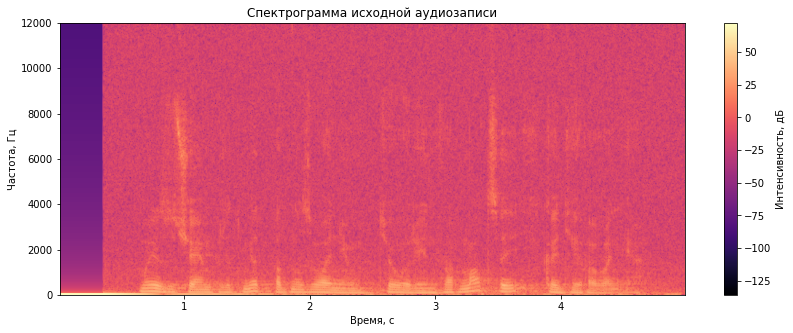

In [27]:
plt.figure(figsize=(14, 5))

plt.specgram(
    audio1,
    NFFT=1024,
    Fs=sample_rate1,
    noverlap=768,
    cmap="magma"
)

plt.title("Спектрограмма исходной аудиозаписи")
plt.xlabel("Время, с")
plt.ylabel("Частота, Гц")
plt.colorbar(label="Интенсивность, дБ")
plt.ylim(0, min(12_000, sample_rate1 / 2))
plt.show()

| Самостоятельно
* постройте спектрограмму для записанной тишины
* какие частоты присуствуют в записи голоса, какие - в записи тишины? Отличается ли их интенсивность?
* можно ли отличить запись тишины от записи голоса по спектрограмме? можно ли выделить моменты тишины на спектрограмме записи голоса?

In [ ]:
# постройте спектрограммы

выводы по спектрограммам:


## Передискретизация и переквантование

Давайте попробуем преобразовать нашу запись, понизив (а затем и повысив тоже!) частоту дискретизации и количество уровней квантования.



In [ ]:
old_rate = 44100
target_rates = [22_050, 11_025, 7_350, 4_410]  # все кратны 44100

resampled_versions = {}

for target_rate in target_rates:
    step = 44100 // target_rate  # деление нацело
    
    resampled = audio1[::step]
    resampled_versions[target_rate] = resampled

    print("Тип данных:", resampled.dtype)
    print("Форма массива:", resampled.shape)
    print("Первые 10 отсчётов:", resampled[:10])
    print("10 отсчётов, начиная с 1 секунды:", audio1[target_rate:target_rate + 10])

Тип данных: int16
Форма массива: (110263,)
Первые 10 отсчётов: [32767 32767 32767 32767 32767 32767 32767 32767 32767 32767]
10 отсчётов, начиная с 1 секунды: [11452 11453 11516 11527 11510 11489 11499 11490 11430 11478]
Тип данных: int16
Форма массива: (55132,)
Первые 10 отсчётов: [32767 32767 32767 32767 32767 32767 32767 32767 32767 32767]
10 отсчётов, начиная с 1 секунды: [32767 32767 32767 32767 32767 32767 32767 32767 32767 32767]
Тип данных: int16
Форма массива: (36755,)
Первые 10 отсчётов: [32767 32767 32767 32767 32767 32767 32767 32767 32767 32767]
10 отсчётов, начиная с 1 секунды: [32767 32767 32767 32767 32767 32767 32767 32767 32767 32767]
Тип данных: int16
Форма массива: (22053,)
Первые 10 отсчётов: [32767 32767 32767 32767 32767 32767 32767 32767 32767 32767]
10 отсчётов, начиная с 1 секунды: [32767 32767 32767 32767 32767 32767 32767 32767 32767 32767]


Проиграйте все получившиеся записи и сравните с оригиналом в следующей ячейке, выберите минимально приемлимый вариант.

In [ ]:
# проиграйте все получившиеся записи

Постройте спектрограммы всех вариантов и сравните их между собой. Что мы теряем, уменьшая частоту ддискретизации?

In [ ]:
# постройте спетрограммы всех получившихся записей

> Обратите внимание:

мы уменьшили объем сообщения, не потеряв **смысловой** информации. Однако каую-то информацию мы теряли. Попробуем определить, какую.